# Load data

## Import necessary libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
# import seaborn as sns
import numpy as np
import json
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## Set global variables

In [6]:
# Set style for better plots
# plt.style.use('seaborn-v0_8-paper')
# sns.set_palette("muted")

# Set style for paper-like plots
# plt.style.use(['science','ieee','no-latex'])
plt.style.use(['science','no-latex'])


# Global configuration for plot duration limit
# This is the maximum duration for which we will plot individual requests
# Necessary because malicious requests require longer to be interrupted in the tests
PLOT_DURATION_LIMIT = 60

## Load and preprocess the data

In [7]:
def load_latest_test_data(src_dir="./"):
    """Load the most recent test data"""
    # Look for both regular and malicious data files
    regular_files = glob.glob(f"{src_dir}/fairness_test_data_regular_*.csv")
    malicious_files = glob.glob(f"{src_dir}/fairness_test_data_malicious_*.csv")
    
    if not regular_files and not malicious_files:
        raise FileNotFoundError("No test data files found")
    
    # Get the latest timestamp
    all_files = regular_files + malicious_files
    latest_file = max(all_files)
    timestamp = latest_file.split('_')[-1].split('.')[0]
    
    # Load both regular and malicious data
    dfs = []
    
    regular_file = f"{src_dir}/fairness_test_data_regular_{timestamp}.csv"
    malicious_file = f"{src_dir}/fairness_test_data_malicious_{timestamp}.csv"
    
    if glob.glob(regular_file):
        df_regular = pd.read_csv(regular_file)
        dfs.append(df_regular)
    
    if glob.glob(malicious_file):
        df_malicious = pd.read_csv(malicious_file)
        dfs.append(df_malicious)
    
    if not dfs:
        raise FileNotFoundError(f"No data files found for timestamp {timestamp}")
    
    # Combine the dataframes
    df = pd.concat(dfs, ignore_index=True)
    
    # Load metadata
    metadata_file = f"{src_dir}/fairness_test_metadata_{timestamp}.json"
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    
    return df, metadata, timestamp

def preprocess_data(df, metadata):
    """Preprocess the individual request data"""
    # Convert start_time to numeric if it's not already
    df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
    
    # Calculate elapsed seconds from the start of the test
    min_time = df['start_time'].min()
    df['elapsed_seconds'] = df['start_time'] - min_time
    
    # Convert duration from milliseconds to seconds for easier analysis
    df['duration_seconds'] = df['duration_ms'] / 1000.0
    
    # Calculate relative increase from baseline for each request
    baseline_latency = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    df['relative_increase_percent'] = ((df['duration_ms'] - baseline_latency) / baseline_latency) * 100
    
    # Sort by time for proper plotting
    df = df.sort_values(['role', 'elapsed_seconds']).reset_index(drop=True)
    
    return df


## Plot functions

In [8]:

def aggregate_data_by_time_window(df, window_size=1.0):
    """Aggregate individual requests into time windows for analysis"""
    aggregated_data = []
    
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
        
        # Create time bins
        max_time = role_data['elapsed_seconds'].max()
        time_bins = np.arange(0, max_time + window_size, window_size)
        
        for i in range(len(time_bins) - 1):
            bin_start = time_bins[i]
            bin_end = time_bins[i + 1]
            
            # Find all requests within this time bin
            bin_mask = (role_data['elapsed_seconds'] >= bin_start) & (role_data['elapsed_seconds'] < bin_end)
            bin_data = role_data[bin_mask]
            
            if len(bin_data) > 0:
                # Calculate aggregated metrics for this window
                avg_latency = bin_data['duration_ms'].mean()
                std_latency = bin_data['duration_ms'].std()
                error_rate = bin_data['is_error'].mean()
                total_requests = len(bin_data)
                
                aggregated_data.append({
                    'time_window_start': bin_start,
                    'time_window_end': bin_end,
                    'time_window_center': (bin_start + bin_end) / 2,
                    'role': role,
                    'avg_latency_ms': avg_latency,
                    'std_latency_ms': std_latency,
                    'error_rate': error_rate,
                    'total_requests': total_requests,
                    'requests_per_second': total_requests / window_size
                })
    
    return pd.DataFrame(aggregated_data)

def plot_individual_requests_scatter(df, metadata, timestamp, save_plots=True, out_dir="./"):   
    """Plot individual request latencies as scatter plot"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Individual request latencies
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Use different markers for successful vs failed requests
        success_data = role_data[~role_data['is_error']]
        error_data = role_data[role_data['is_error']]
        
        if len(success_data) > 0:
            ax1.scatter(success_data['elapsed_seconds'], success_data['duration_ms'], 
                       label=f'{role} Tenant (Success)', alpha=0.6, s=10)
        
        if len(error_data) > 0:
            ax1.scatter(error_data['elapsed_seconds'], error_data['duration_ms'], 
                       label=f'{role} Tenant (Error)', alpha=0.8, s=15, marker='x')
    
    # Add baseline line
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Request Latency (ms)')
    ax1.set_title('Individual Request Latencies Over Time')
    ax1.set_xlim(0, PLOT_DURATION_LIMIT)
    ax1.legend()
    
    # Plot 2: Moving average with confidence intervals
    window_size = 1.0  # 1-second moving window
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Calculate rolling statistics
        role_data_sorted = role_data.sort_values('elapsed_seconds')
        
        # Create time bins for rolling average
        max_time = role_data_sorted['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)  # Every second
        
        rolling_mean = []
        rolling_std = []
        valid_time_points = []
        
        for t in time_points:
            # Get data within window_size/2 around this time point
            window_mask = (role_data_sorted['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data_sorted['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data_sorted[window_mask]
            
            #if len(window_data) >= 5:  # Only if we have enough data points
            rolling_mean.append(window_data['duration_ms'].mean())
            rolling_std.append(window_data['duration_ms'].std())
            valid_time_points.append(t)
        
        if rolling_mean:
            rolling_mean = np.array(rolling_mean)
            rolling_std = np.array(rolling_std)
            valid_time_points = np.array(valid_time_points)
            
            ax2.plot(valid_time_points, rolling_mean, label=f'{role} Tenant (Moving Avg)', linewidth=2)
            ax2.fill_between(valid_time_points, 
                           rolling_mean - rolling_std, 
                           rolling_mean + rolling_std, 
                           alpha=0.2)
    
    ax2.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Average Latency (ms)')
    ax2.set_ylim(bottom=0)
    ax2.set_title(f'Moving Average Latency ({window_size}s window)')
    ax2.set_xlim(0, PLOT_DURATION_LIMIT)
    ax2.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{out_dir}/individual_requests_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
def plot_relative_increase(df, metadata, timestamp, save_plots=True, out_dir="./"):
    """Plot relative increase in latency compared to baseline as a moving average"""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Calculate rolling average of relative increase
    window_size = 1.0  # 1-second moving window
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Sort by elapsed time
        role_data_sorted = role_data.sort_values('elapsed_seconds')
        
        # Create time bins for rolling average
        max_time = role_data_sorted['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)  # Every second
        
        rolling_mean = []
        rolling_std = []
        valid_time_points = []
        
        for t in time_points:
            # Get data within window_size/2 around this time point
            window_mask = (role_data_sorted['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data_sorted['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data_sorted[window_mask]
            
            if len(window_data) >= 3:  # Only if we have enough data points
                rolling_mean.append(window_data['relative_increase_percent'].mean())
                rolling_std.append(window_data['relative_increase_percent'].std())
                valid_time_points.append(t)
        
        if rolling_mean:
            rolling_mean = np.array(rolling_mean)
            rolling_std = np.array(rolling_std)
            valid_time_points = np.array(valid_time_points)
            
            ax.plot(valid_time_points, rolling_mean, label=f'{role} Tenant', linewidth=2)
            ax.fill_between(valid_time_points, 
                           rolling_mean - rolling_std, 
                           rolling_mean + rolling_std, 
                           alpha=0.2)
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Relative Increase (%)')
    ax.set_ylim(bottom=0)
    ax.set_title('Average Relative Latency Increase from a non contended environment (1s window)')
    ax.set_xlim(0, PLOT_DURATION_LIMIT)
    ax.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{out_dir}/relative_increase_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_error_analysis(df, metadata, timestamp, save_plots=True, out_dir="./"):
    """Plot error analysis for individual requests"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Error rate over time (aggregated by windows)
    aggregated_df = aggregate_data_by_time_window(df, window_size=1.0)
    
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax1.plot(role_data['time_window_center'], role_data['error_rate'] * 100, 
                label=f'{role} Tenant', marker='o', markersize=4)
    
    ax1.axhline(y=5,  linestyle='--', alpha=0.7, label='Failure Threshold (5%)')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Error Rate (%)')
    ax1.set_title('Error Rate Over Time (1s windows)')
    ax1.set_xlim(0, PLOT_DURATION_LIMIT)
    ax1.legend()
    
    # 2. Error distribution by operation type
    error_by_operation = df.groupby(['role', 'operation'])['is_error'].agg(['count', 'sum', 'mean']).reset_index()
    error_by_operation['error_rate'] = error_by_operation['mean'] * 100
    
    operations = error_by_operation['operation'].unique()
    x_pos = np.arange(len(operations))
    width = 0.35
    
    for i, role in enumerate(error_by_operation['role'].unique()):
        role_data = error_by_operation[error_by_operation['role'] == role]
        values = [role_data[role_data['operation'] == op]['error_rate'].iloc[0] 
                 if len(role_data[role_data['operation'] == op]) > 0 else 0 
                 for op in operations]
        ax2.bar(x_pos + i * width, values, width, label=f'{role} Tenant')
    
    ax2.set_xlabel('Operation Type')
    ax2.set_ylabel('Error Rate (%)')
    ax2.set_title('Error Rate by Operation Type')
    ax2.set_xticks(x_pos + width / 2)
    ax2.set_xticklabels(operations)
    ax2.legend()
    
    # 3. Latency distribution (box plot)
    latency_data = []
    labels = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) > 0:
            latency_data.append(role_data['duration_ms'].values)
            labels.append(f'{role}\n(n={len(role_data)})')
    
    if latency_data:
        ax3.boxplot(latency_data, labels=labels, showfliers=False)
    ax3.set_ylabel('Latency (ms)')
    ax3.set_title('Latency Distribution by Role')
    
    # 4. Request throughput over time
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax4.plot(role_data['time_window_center'], role_data['requests_per_second'], 
                label=f'{role} Tenant', marker='o', markersize=4)
    
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Requests per Second')
    ax4.set_title('Request Throughput Over Time')
    ax4.set_xlim(0, PLOT_DURATION_LIMIT)
    ax4.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{out_dir}/error_analysis_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_summary_dashboard(df, metadata, timestamp, save_plots=True, out_dir="./"):
    """Create a comprehensive dashboard for individual request data"""
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    # 1. Moving average latency (top row, full width)
    ax1 = fig.add_subplot(gs[0, :])
    window_size = 1.0
    for role in df['role'].unique():
        role_data = df[df['role'] == role].sort_values('elapsed_seconds')
        if len(role_data) == 0:
            continue
        
        # Calculate rolling average
        max_time = role_data['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)
        rolling_mean = []
        valid_time_points = []
        
        for t in time_points:
            window_mask = (role_data['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data[window_mask]
            
            if len(window_data) >= 3:
                rolling_mean.append(window_data['duration_ms'].mean())
                valid_time_points.append(t)
        
        if rolling_mean:
            ax1.plot(valid_time_points, rolling_mean, label=f'{role} Tenant', linewidth=2)
    
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    ax1.set_title('Average Request Latency Over Time')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_xlim(0, PLOT_DURATION_LIMIT)
    ax1.legend()
    
    # 2. Error rates (second row, left)
    ax2 = fig.add_subplot(gs[1, 0])
    aggregated_df = aggregate_data_by_time_window(df, window_size=1.0)
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax2.plot(role_data['time_window_center'], role_data['error_rate'] * 100, 
                label=f'{role}', marker='o', markersize=3)
    ax2.axhline(y=5,  linestyle='--', alpha=0.7, label='Threshold')
    ax2.set_title('Error Rate Over Time')
    ax2.set_ylabel('Error Rate (%)')
    ax2.legend()
    
    # 3. Latency distribution (second row, middle)
    ax3 = fig.add_subplot(gs[1, 1])
    latency_data = []
    labels = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) > 0:
            latency_data.append(role_data['duration_ms'].values)
            labels.append(role)
    
    if latency_data:
        ax3.boxplot(latency_data, labels=labels, showfliers=False)
    ax3.set_title('Latency Distribution')
    ax3.set_ylabel('Latency (ms)')
    
    # 4. Request throughput (second row, right)
    ax4 = fig.add_subplot(gs[1, 2])
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax4.plot(role_data['time_window_center'], role_data['requests_per_second'], 
                label=f'{role}', marker='o', markersize=3)
    ax4.set_title('Throughput Over Time')
    ax4.set_ylabel('Requests/sec')
    ax4.set_xlim(0, PLOT_DURATION_LIMIT)
    ax4.legend()
    
    # 5. Operation type analysis (third row, left and middle)
    ax5 = fig.add_subplot(gs[2, :2])
    operation_stats = df.groupby(['role', 'operation']).agg({
        'duration_ms': ['count', 'mean', 'std'],
        'is_error': 'mean'
    }).round(2)
    
    # Flatten column names
    operation_stats.columns = ['_'.join(col).strip() for col in operation_stats.columns]
    operation_stats = operation_stats.reset_index()
    
    # Create a grouped bar chart for average latency by operation
    operations = operation_stats['operation'].unique()
    x_pos = np.arange(len(operations))
    width = 0.35
    
    for i, role in enumerate(operation_stats['role'].unique()):
        role_data = operation_stats[operation_stats['role'] == role]
        values = [role_data[role_data['operation'] == op]['duration_ms_mean'].iloc[0] 
                 if len(role_data[role_data['operation'] == op]) > 0 else 0 
                 for op in operations]
        ax5.bar(x_pos + i * width, values, width, label=f'{role} Tenant')
    
    ax5.set_title('Average Latency by Operation Type')
    ax5.set_ylabel('Average Latency (ms)')
    ax5.set_xticks(x_pos + width / 2)
    ax5.set_xticklabels(operations)
    ax5.legend()
    
    # 6. Resource type analysis (third row, right)
    ax6 = fig.add_subplot(gs[2, 2])
    resource_stats = df.groupby(['role', 'resource']).agg({
        'duration_ms': 'mean',
        'is_error': 'mean'
    }).reset_index()
    
    resources = resource_stats['resource'].unique()
    x_pos = np.arange(len(resources))
    
    for i, role in enumerate(resource_stats['role'].unique()):
        role_data = resource_stats[resource_stats['role'] == role]
        values = [role_data[role_data['resource'] == res]['duration_ms'].iloc[0] 
                 if len(role_data[role_data['resource'] == res]) > 0 else 0 
                 for res in resources]
        ax6.bar(x_pos + i * width, values, width, label=f'{role}')
    
    ax6.set_title('Avg Latency by Resource')
    ax6.set_ylabel('Latency (ms)')
    ax6.set_xticks(x_pos + width / 2)
    ax6.set_xticklabels(resources)
    ax6.legend()
    
    # 7. Summary statistics table (bottom row)
    ax7 = fig.add_subplot(gs[3, :])
    ax7.axis('tight')
    ax7.axis('off')
    
    summary_data = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
            
        avg_latency = role_data['duration_ms'].mean()
        median_latency = role_data['duration_ms'].median()
        p95_latency = role_data['duration_ms'].quantile(0.95)
        std_latency = role_data['duration_ms'].std()
        error_rate = role_data['is_error'].mean()
        total_requests = len(role_data)
        
        summary_data.append([
            role,
            f"{total_requests:,}",
            f"{avg_latency:.1f}ms",
            f"{median_latency:.1f}ms", 
            f"{p95_latency:.1f}ms",
            f"{std_latency:.1f}ms",
            f"{error_rate * 100:.2f}%"
        ])
    
    if summary_data:
        table = ax7.table(cellText=summary_data,
                          colLabels=['Tenant', 'Total Requests', 'Avg Latency', 
                                   'Median Latency', 'P95 Latency', 'Std Dev', 'Error Rate'],
                          cellLoc='center',
                          loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)
    ax7.set_title('Individual Request Statistics Summary', pad=20)
    
    # Add test result
    test_result = "PASSED" if metadata.get('test_passed', False) else "FAILED"
    fig.suptitle(f'Fairness Test Analysis - Individual Requests - {test_result}', 
                 fontsize=16, fontweight='bold')
    
    if save_plots:
        plt.savefig(f'{out_dir}/individual_requests_dashboard_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_test_summary(df, metadata):
    """Print a detailed test summary for individual request data"""
    print("=" * 70)
    print("FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS")
    print("=" * 70)
    
    config = metadata.get('test_config', {})
    baseline = metadata.get('baseline_metrics', {})
    final = metadata.get('final_results', {})
    
    print(f"Test Result: {'✅ PASSED' if metadata.get('test_passed', False) else '❌ FAILED'}")
    print()
    
    print("Test Configuration:")
    print(f"  Regular Requesters: {config.get('regular_requesters', 'N/A')}")
    print(f"  Malicious Requesters: {config.get('malicious_requesters', 'N/A')}")
    print(f"  Regular Request Rate: {config.get('regular_request_rate', 'N/A')}/s")
    print(f"  Malicious Request Rate: {config.get('malicious_request_rate', 'N/A')}/s")
    print(f"  Test Duration: {config.get('test_duration', {}).get('secs', 'N/A')}s")
    print()
    
    print("Individual Request Statistics:")
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        print(f"\n  {role} Tenant:")
        print(f"    Total Requests: {len(role_data):,}")
        print(f"    Average Latency: {role_data['duration_ms'].mean():.1f}ms")
        print(f"    Median Latency: {role_data['duration_ms'].median():.1f}ms")
        print(f"    95th Percentile: {role_data['duration_ms'].quantile(0.95):.1f}ms")
        print(f"    Standard Deviation: {role_data['duration_ms'].std():.1f}ms")
        print(f"    Error Rate: {role_data['is_error'].mean() * 100:.2f}%")
        print(f"    Successful Requests: {(~role_data['is_error']).sum():,}")
        print(f"    Failed Requests: {role_data['is_error'].sum():,}")
    
    print(f"\nBaseline Comparison:")
    baseline_latency = baseline.get('tenant1_avg_latency_ms', 0)
    regular_data = df[df['role'] == 'Regular']
    if len(regular_data) > 0:
        current_avg = regular_data['duration_ms'].mean()
        increase = ((current_avg - baseline_latency) / baseline_latency * 100) if baseline_latency > 0 else 0
        print(f"  Baseline Latency: {baseline_latency:.1f}ms")
        print(f"  Current Avg Latency: {current_avg:.1f}ms")
        print(f"  Relative Increase: {increase:.1f}%")

# Main analysis function
def analyze_fairness_test(src_dir="./", out_dir="./"):
    """Run complete analysis for individual request data"""
    try:
        df, metadata, timestamp = load_latest_test_data(src_dir)
        
        print(f"Loaded {len(df)} individual request records")
        print(f"Data columns: {list(df.columns)}")
        print(f"Time range: {df['start_time'].min():.1f} - {df['start_time'].max():.1f}")
        
        # Preprocess the data
        df = preprocess_data(df, metadata)
        
        print_test_summary(df, metadata)
        print("\nGenerating plots...")
        
        plot_individual_requests_scatter(df, metadata, timestamp, save_plots=True, out_dir=out_dir)
        plot_relative_increase(df, metadata, timestamp, save_plots=True, out_dir=out_dir)
        plot_error_analysis(df, metadata, timestamp, save_plots=True, out_dir=out_dir)
        plot_summary_dashboard(df, metadata, timestamp, save_plots=True, out_dir=out_dir)
        
        print(f"\nAnalysis complete! Plots saved with timestamp: {timestamp}")
        print(f"Total individual requests analyzed: {len(df):,}")
        
        return df, metadata
        
    except Exception as e:
        print(f"Error during analysis: {e}")
        import traceback
        traceback.print_exc()
        return None, None

In [73]:
def plot_comparative_latency_distribution(data_dirs, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']
    all_data = {}
    
    # Load data from all solutions
    for solution in solutions:
        try:
            solution_dir = f"{data_dirs}/{solution}/data"
            df, metadata, timestamp = load_latest_test_data(solution_dir)
            df = preprocess_data(df, metadata)
            all_data[solution] = df
            print(f"Loaded {len(df)} records for {solution}")
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    if not all_data:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=600)
    else:
        fig, ax = plt.subplots(figsize=(12, 8), dpi=600)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Regular': colors[0],    # First color from style
        'Malicious': colors[1]   # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in zip(solutions, solutions_label):
        if solution not in all_data:
            continue
            
        df = all_data[solution]
        solution_start_pos = pos
        
        for role in ['Regular', 'Malicious']:
            role_data = df[df['role'] == role]
            if len(role_data) > 0:
                latencies = role_data['duration_ms']
                box_data.append(latencies.values)
                box_labels.append(role)  # Just the role name
                positions.append(pos)
                pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 0.6

    
    # Create box plot
    bp = ax.boxplot(box_data, positions=positions, patch_artist=True, 
                    labels=box_labels, showfliers=False,
                    widths=0.3,
                    medianprops={'color': 'black'})
    
    import matplotlib.colors as mcolors
    # Color the boxes
    for patch, label in zip(bp['boxes'], box_labels):
        patch.set_facecolor(role_colors[label])
        patch.set_alpha(0.6)  # Set transparency for better visibility
        darker_color = mcolors.to_rgb(role_colors[label])
        darker_color = tuple(c * 0.6 for c in darker_color)
        patch.set_edgecolor(darker_color)
        patch.set_linewidth(1)
        
    
    # Customize the plot
    ax.set_ylabel('Request Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add role labels as secondary x-axis
    # for i, pos in enumerate(positions):
    #     role = box_labels[i]
    #     ax.text(pos, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03, 
    #         role, ha='center', va='top', fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious')
    ]
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1), handletextpad=0.25)
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)
    # Add statistics annotations (median values)
    # y_max = ax.get_ylim()[1]
    # for i, (data, label) in enumerate(zip(box_data, box_labels)):
    #     if len(data) > 0:
    #         median_val = np.median(data)
    #         # Add median value as text above each box
    #         ax.text(positions[i], median_val - (ax.get_ylim()[1] * 0.01), f'{median_val:.0f}ms', 
    #            ha='center', va='bottom', fontsize=9, fontweight='bold',
    #            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=1, edgecolor='none'))
    
    plt.tight_layout()
    plt.minorticks_off()
    
    if save_plots:
        plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in all_data:
            continue
            
        print(f"\n{solution.upper()}:")
        df = all_data[solution]
        
        for role in ['Regular', 'Malicious']:
            role_data = df[df['role'] == role]
            if len(role_data) > 0:
                latencies = role_data['duration_ms']
                print(f"  {role} Tenant:")
                print(f"    Requests: {len(latencies):,}")
                print(f"    Mean: {latencies.mean():.1f}ms")
                print(f"    Median: {latencies.median():.1f}ms")
                print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                print(f"    Std Dev: {latencies.std():.1f}ms")

Loaded 136771 records for capsule
Loaded 35745 records for kubezoo
Loaded 361906 records for vcluster
Loaded 112940 records for kubevirt


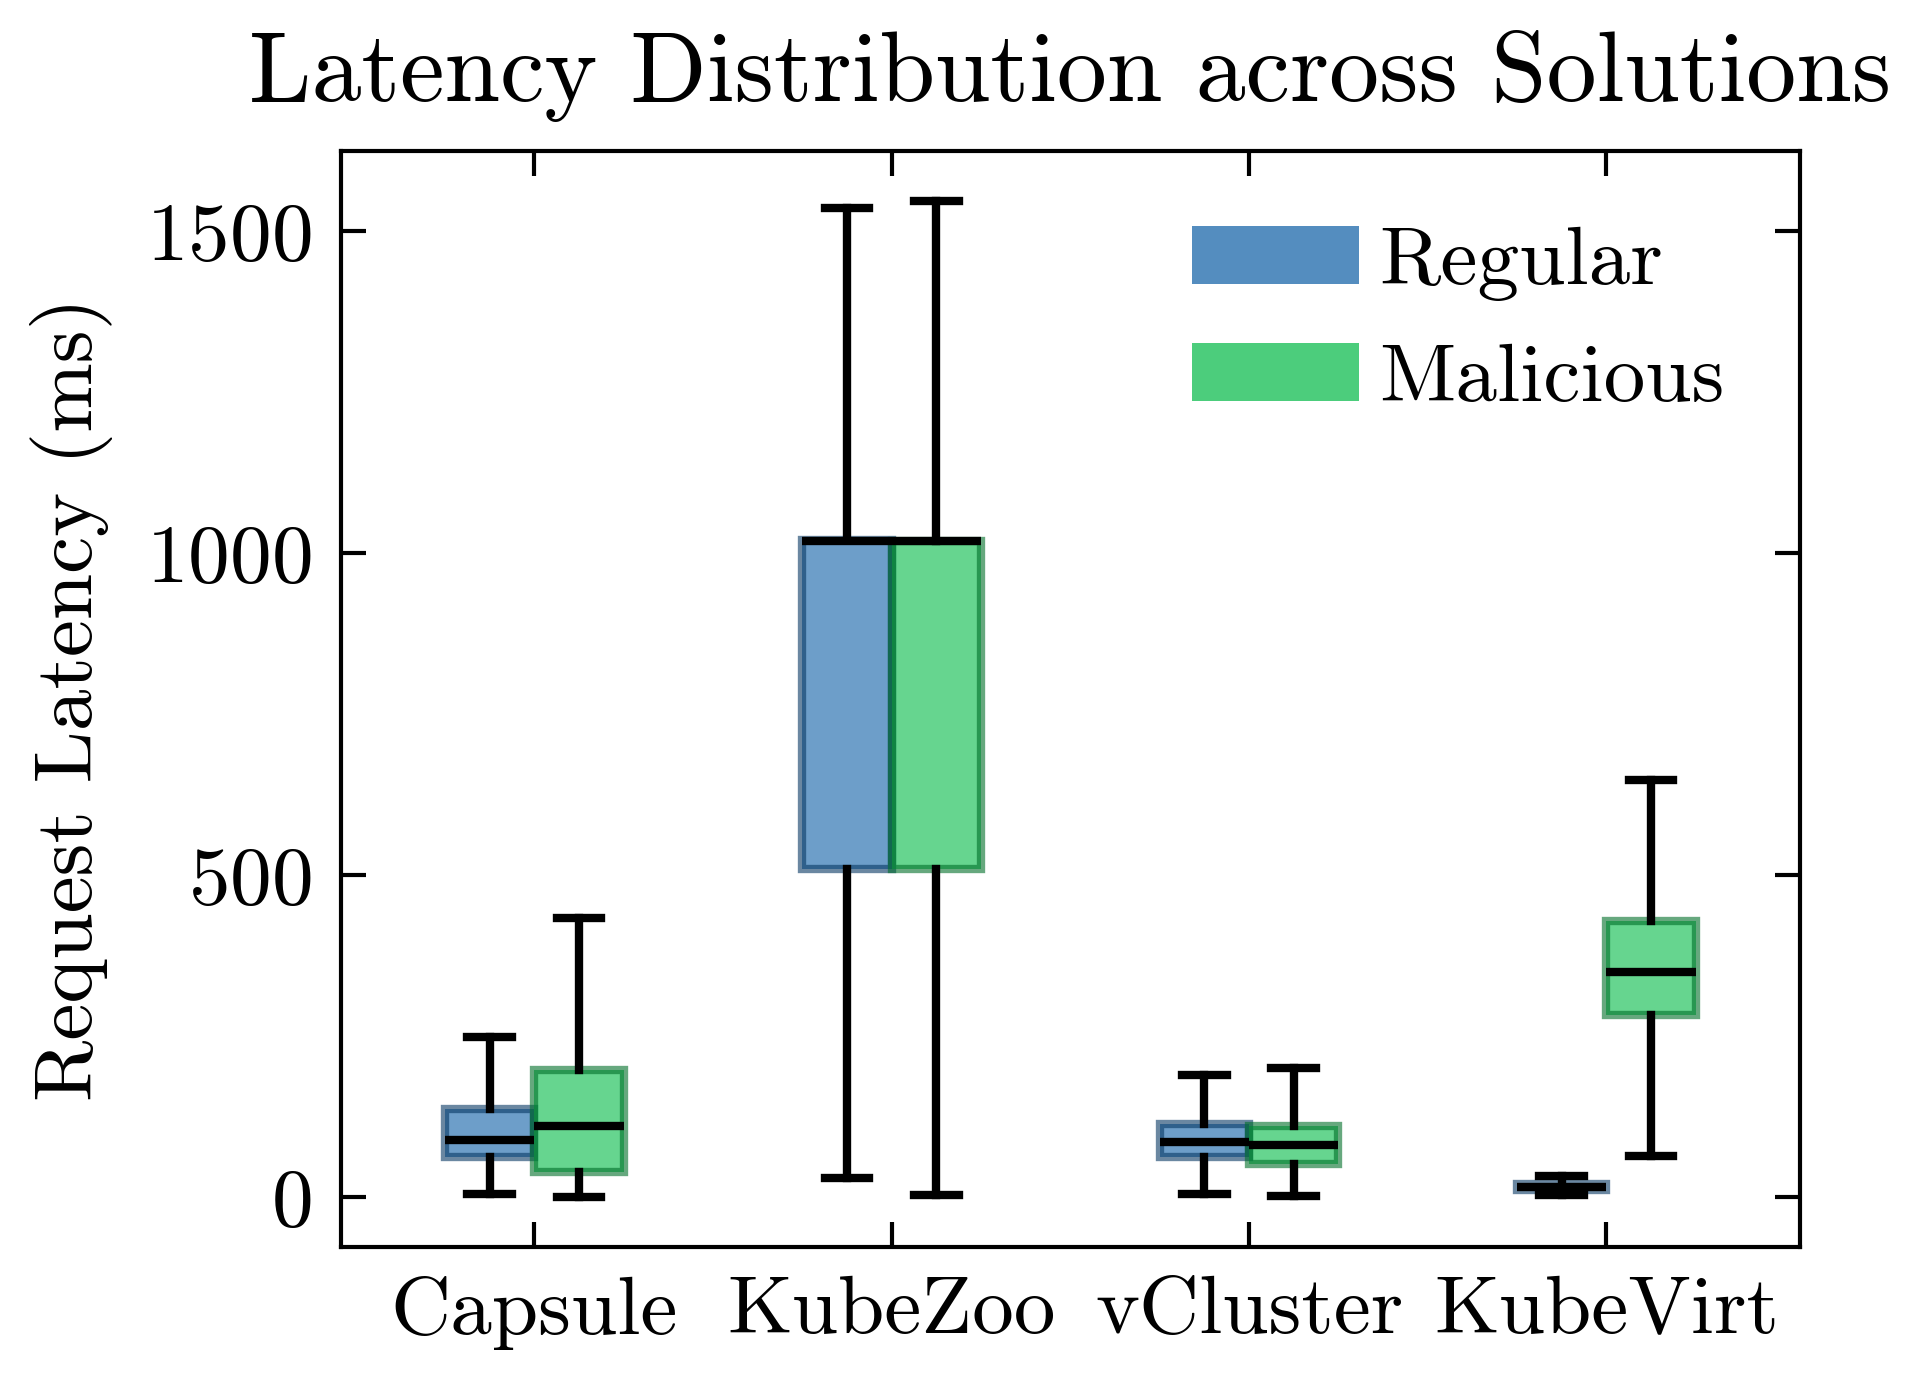


COMPARATIVE LATENCY ANALYSIS

CAPSULE:
  Regular Tenant:
    Requests: 2,891
    Mean: 208.3ms
    Median: 88.0ms
    P95: 1078.0ms
    P99: 2666.8ms
    Std Dev: 458.1ms
  Malicious Tenant:
    Requests: 133,880
    Mean: 225.7ms
    Median: 111.0ms
    P95: 999.0ms
    P99: 2483.0ms
    Std Dev: 446.3ms

KUBEZOO:
  Regular Tenant:
    Requests: 673
    Mean: 906.3ms
    Median: 1018.0ms
    P95: 1531.0ms
    P99: 2549.0ms
    Std Dev: 480.0ms
  Malicious Tenant:
    Requests: 35,072
    Mean: 866.0ms
    Median: 1018.0ms
    P95: 1531.0ms
    P99: 1532.0ms
    Std Dev: 364.2ms

VCLUSTER:
  Regular Tenant:
    Requests: 6,655
    Mean: 89.7ms
    Median: 85.0ms
    P95: 159.0ms
    P99: 196.0ms
    Std Dev: 37.9ms
  Malicious Tenant:
    Requests: 355,251
    Mean: 83.6ms
    Median: 81.0ms
    P95: 152.0ms
    P99: 188.0ms
    Std Dev: 40.4ms

KUBEVIRT:
  Regular Tenant:
    Requests: 30,012
    Mean: 16.3ms
    Median: 15.0ms
    P95: 30.0ms
    P99: 43.0ms
    Std Dev: 7.5ms
  Mal

In [74]:
# plot all comparative latency distribution
plot_comparative_latency_distribution(
    data_dirs="./60_sec",
    save_plots=True,
    out_dir="./plots",
)

## Plot the data using Capsule

Loaded 136771 individual request records
Data columns: ['start_time', 'role', 'duration_ms', 'operation', 'resource', 'is_error']
Time range: 10.0 - 71.8
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 133,880
    Average Latency: 225.7ms
    Median Latency: 111.0ms
    95th Percentile: 999.0ms
    Standard Deviation: 446.3ms
    Error Rate: 28.94%
    Successful Requests: 95,133
    Failed Requests: 38,747

  Regular Tenant:
    Total Requests: 2,891
    Average Latency: 208.3ms
    Median Latency: 88.0ms
    95th Percentile: 1078.0ms
    Standard Deviation: 458.1ms
    Error Rate: 0.07%
    Successful Requests: 2,889
    Failed Requests: 2

Baseline Comparison:
  Baseline Latency: 7.0ms
  Current Avg Latency: 208.3ms
  Relative 

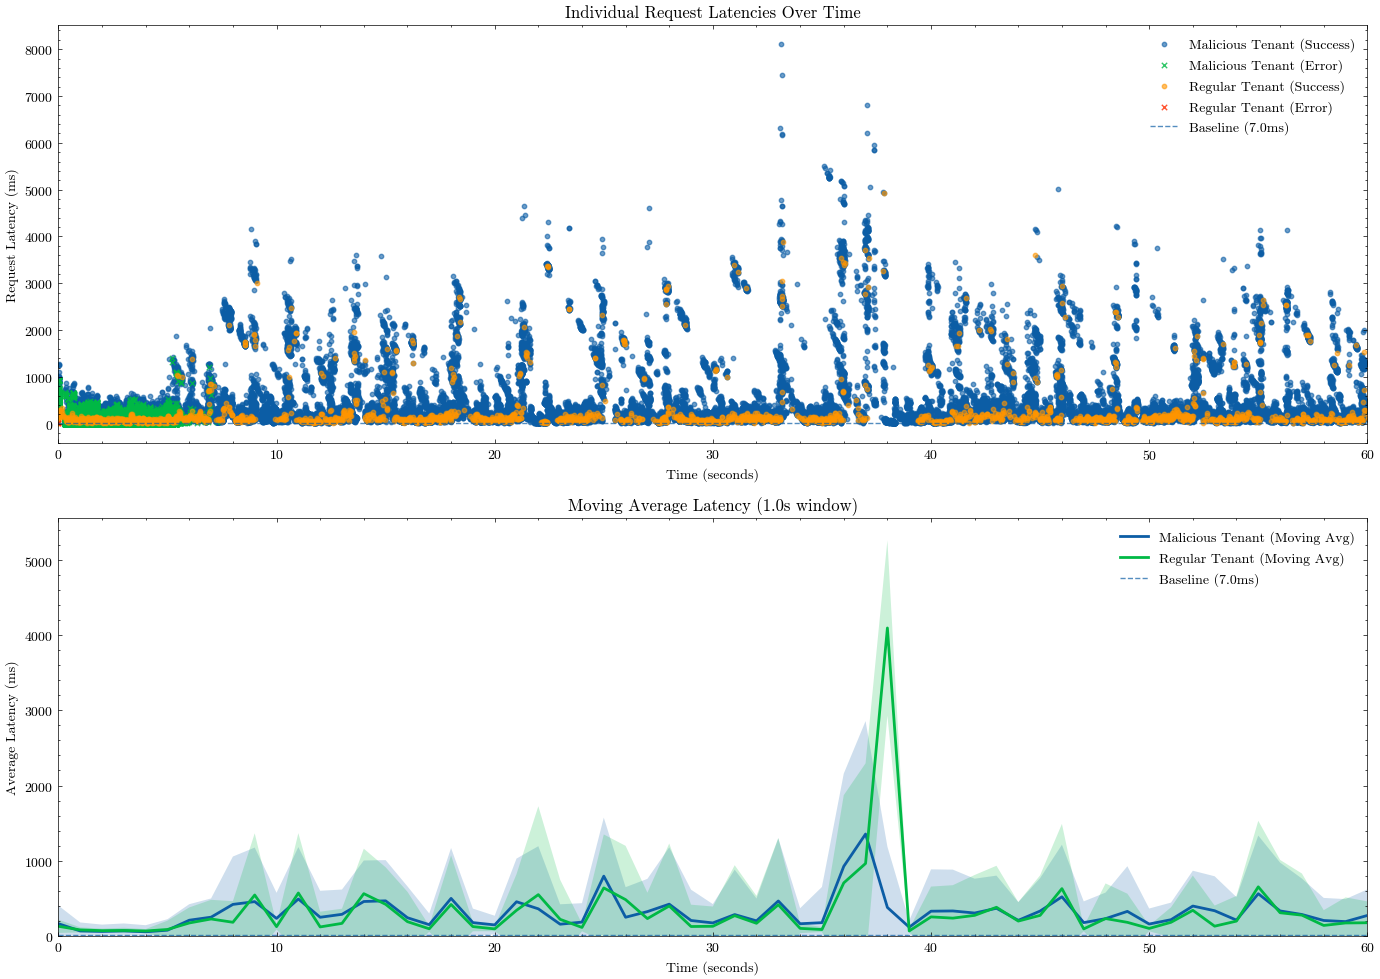

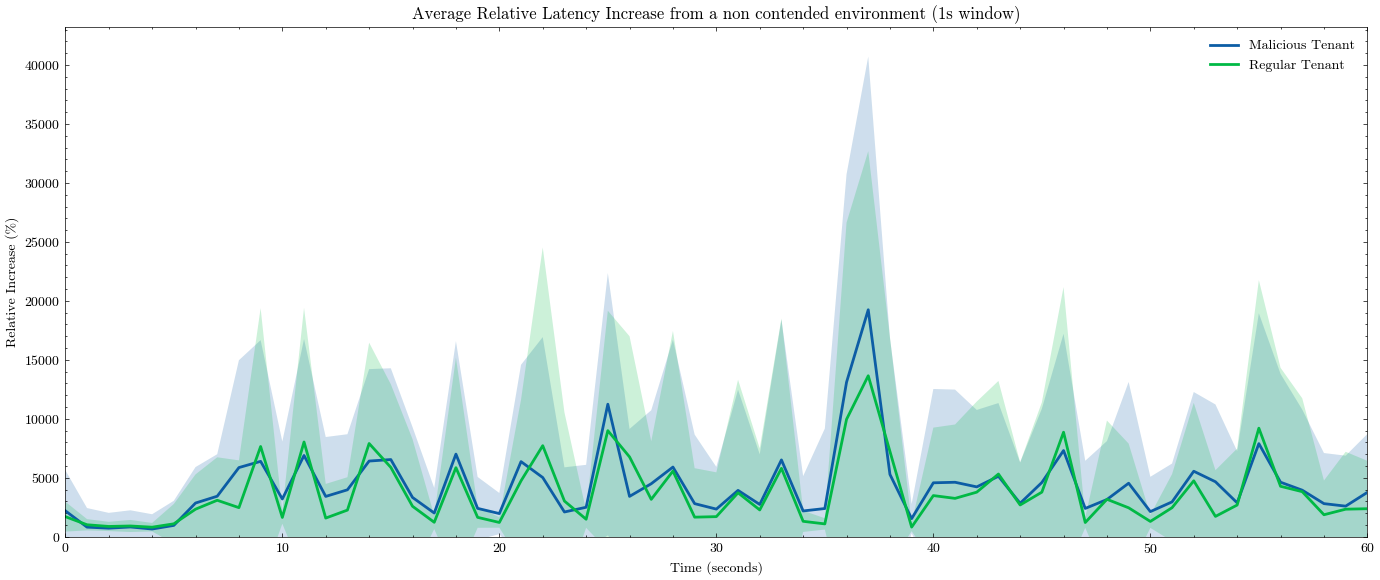

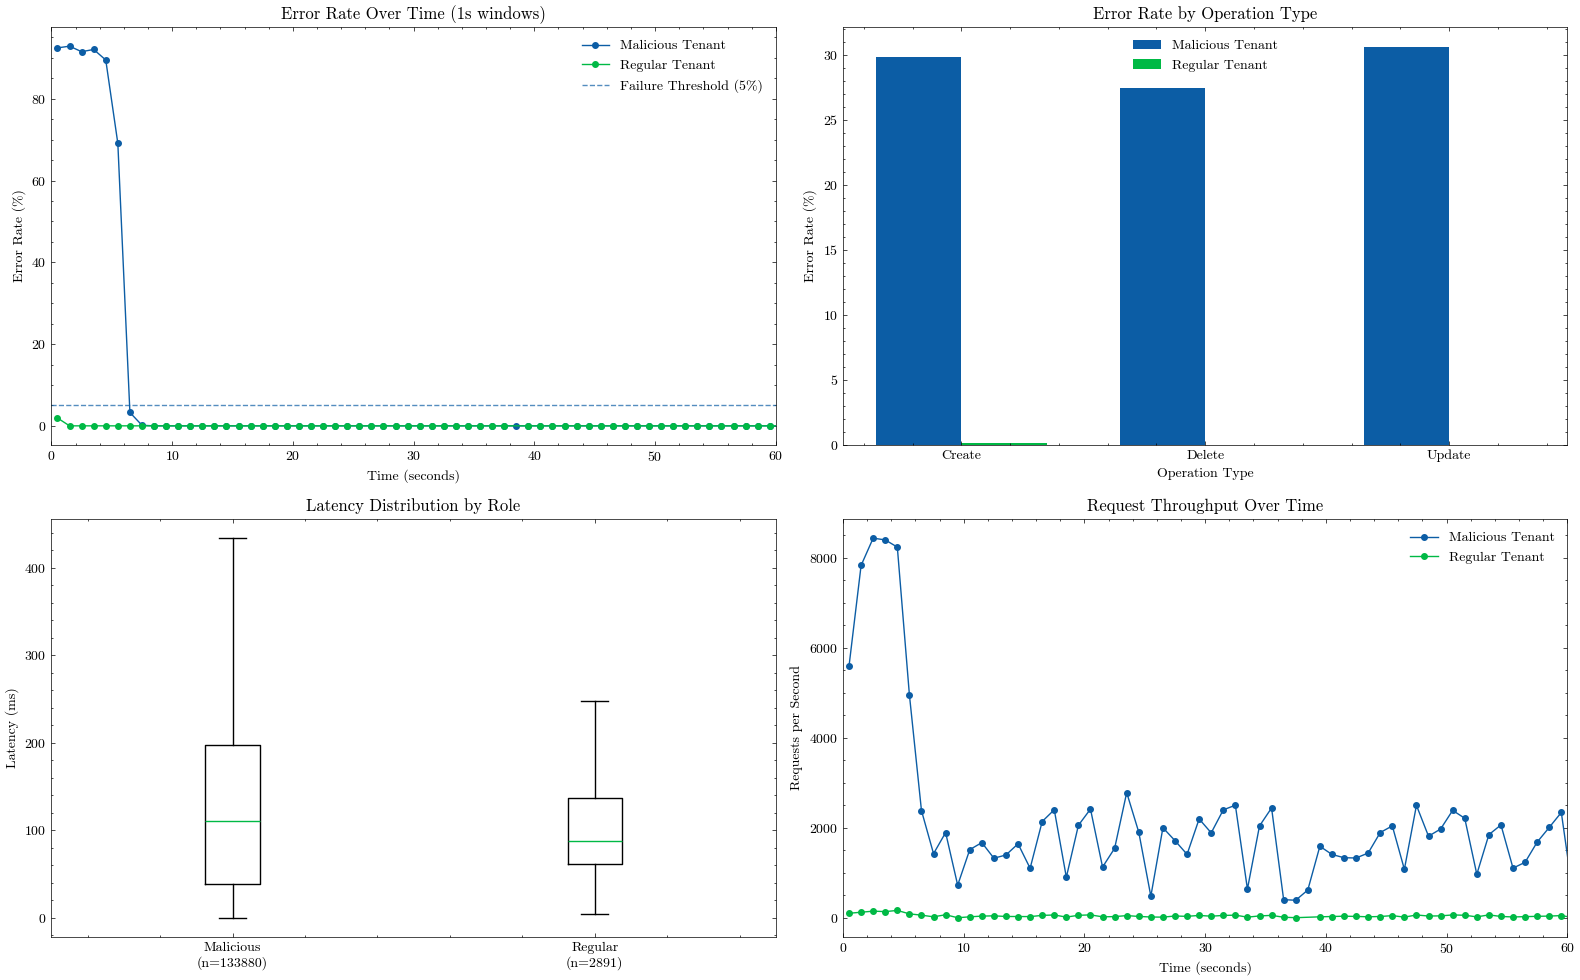

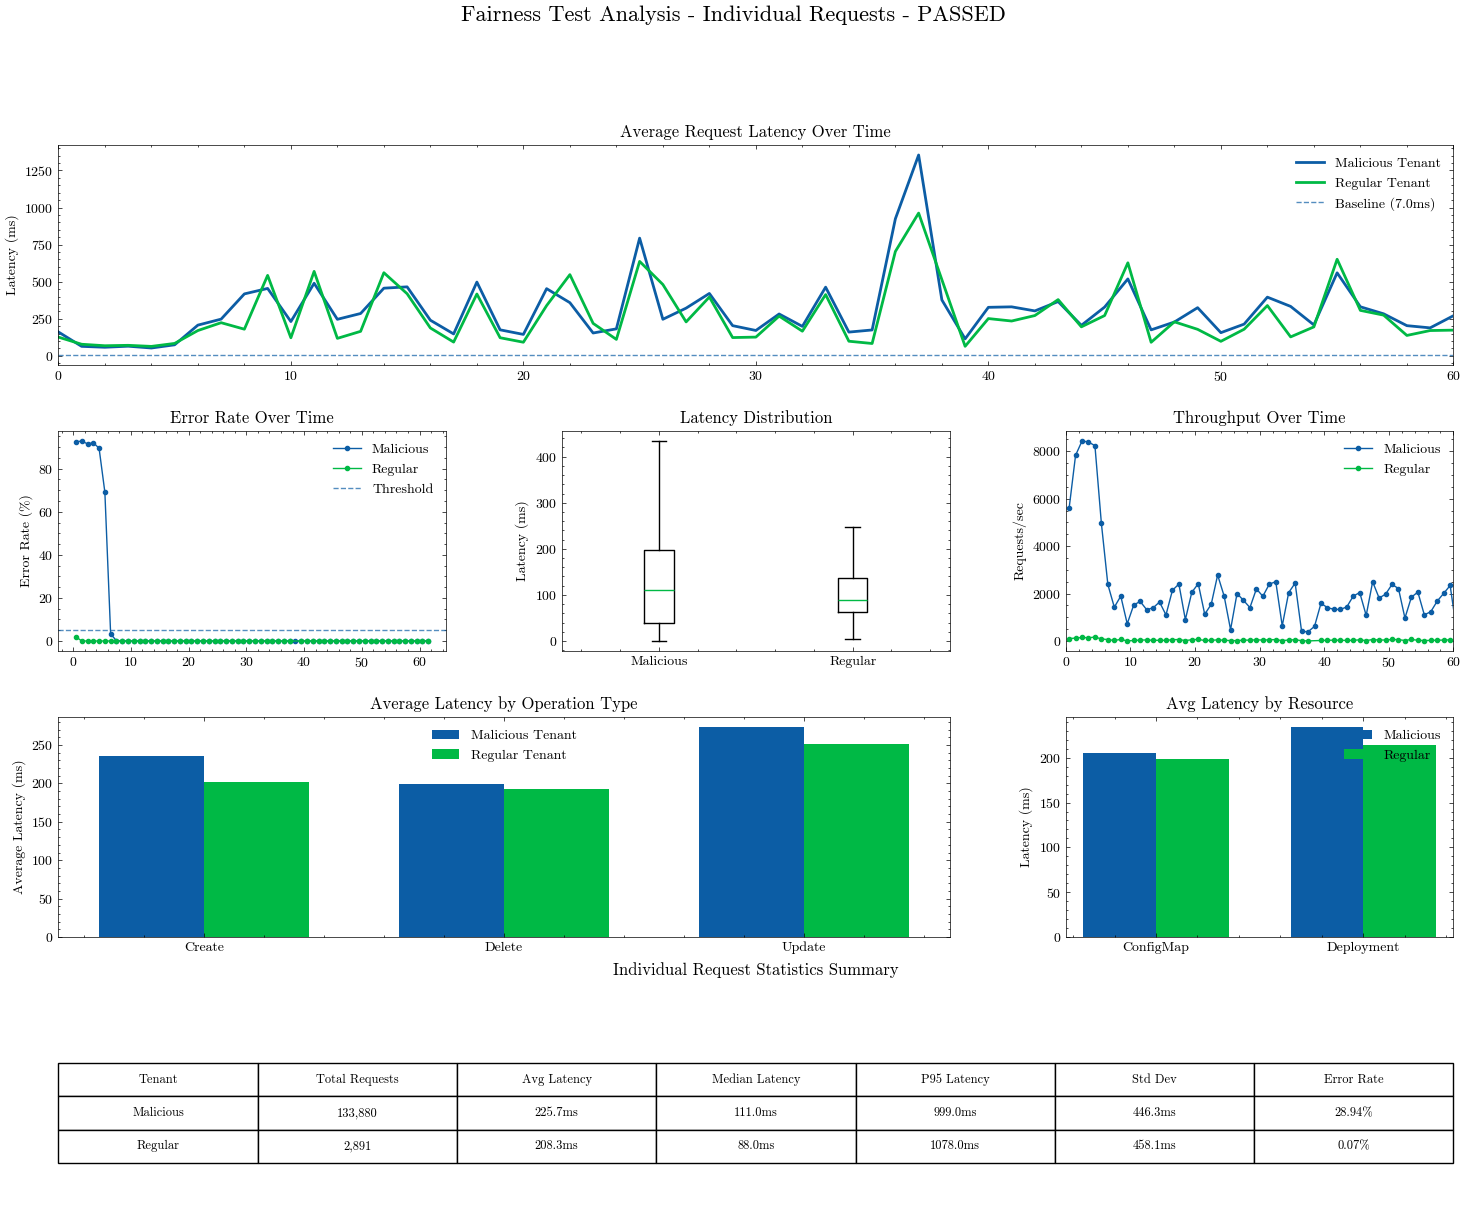


Analysis complete! Plots saved with timestamp: 1749507734
Total individual requests analyzed: 136,771


In [70]:
# Run the analysis
df, metadata = analyze_fairness_test("./60_sec/capsule/data", "./60_sec/capsule/results")

## Plot the data using vCluster

Loaded 361906 individual request records
Data columns: ['start_time', 'role', 'duration_ms', 'operation', 'resource', 'is_error']
Time range: 10.1 - 70.4
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 355,251
    Average Latency: 83.6ms
    Median Latency: 81.0ms
    95th Percentile: 152.0ms
    Standard Deviation: 40.4ms
    Error Rate: 100.00%
    Successful Requests: 0
    Failed Requests: 355,251

  Regular Tenant:
    Total Requests: 6,655
    Average Latency: 89.7ms
    Median Latency: 85.0ms
    95th Percentile: 159.0ms
    Standard Deviation: 37.9ms
    Error Rate: 0.08%
    Successful Requests: 6,650
    Failed Requests: 5

Baseline Comparison:
  Baseline Latency: 6.0ms
  Current Avg Latency: 89.7ms
  Relative Increase: 

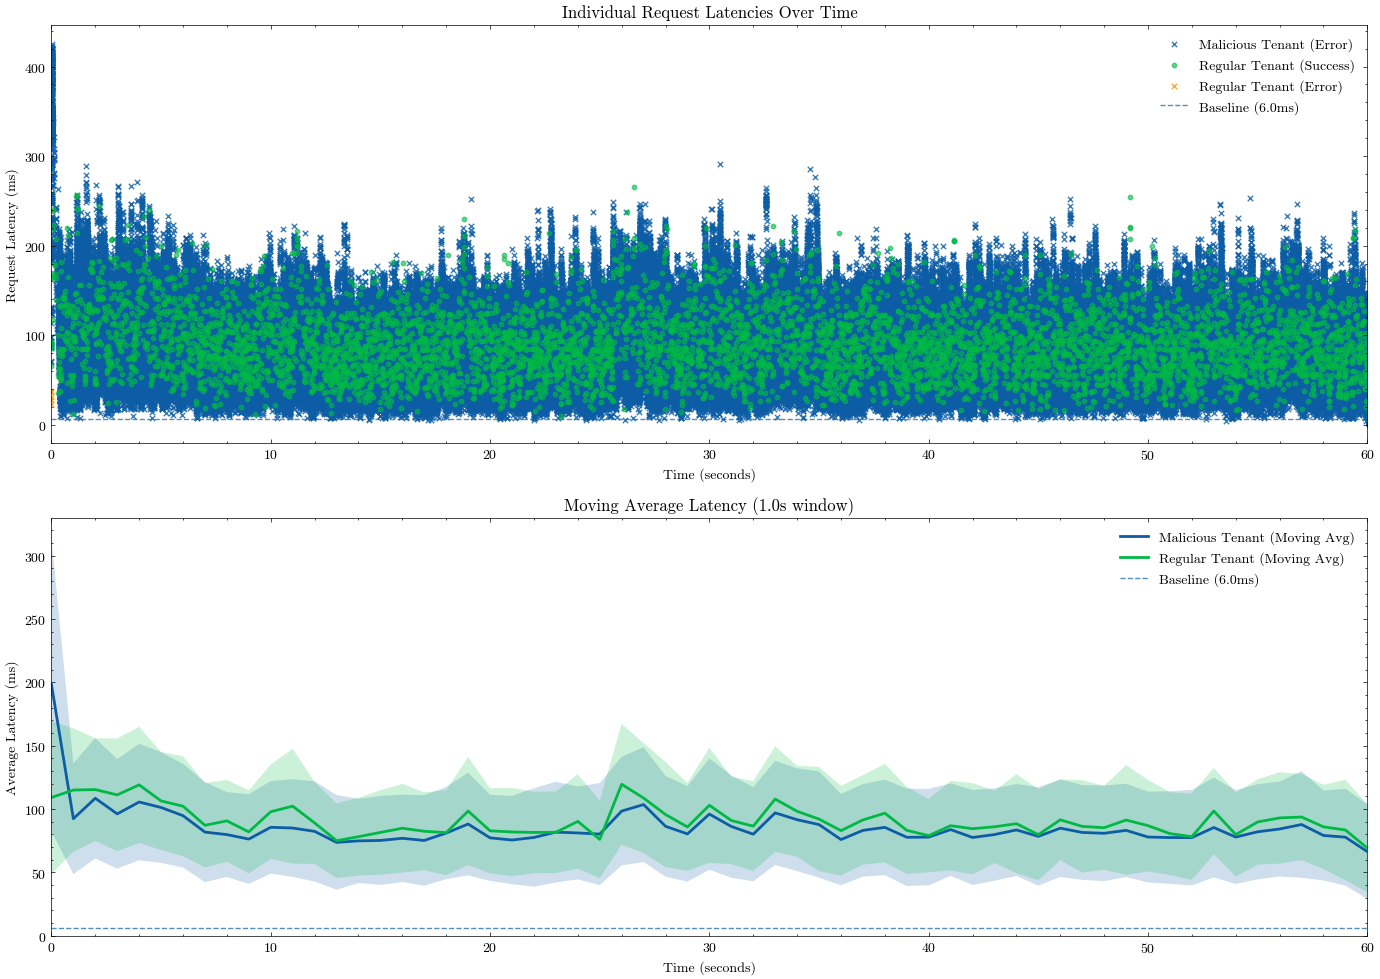

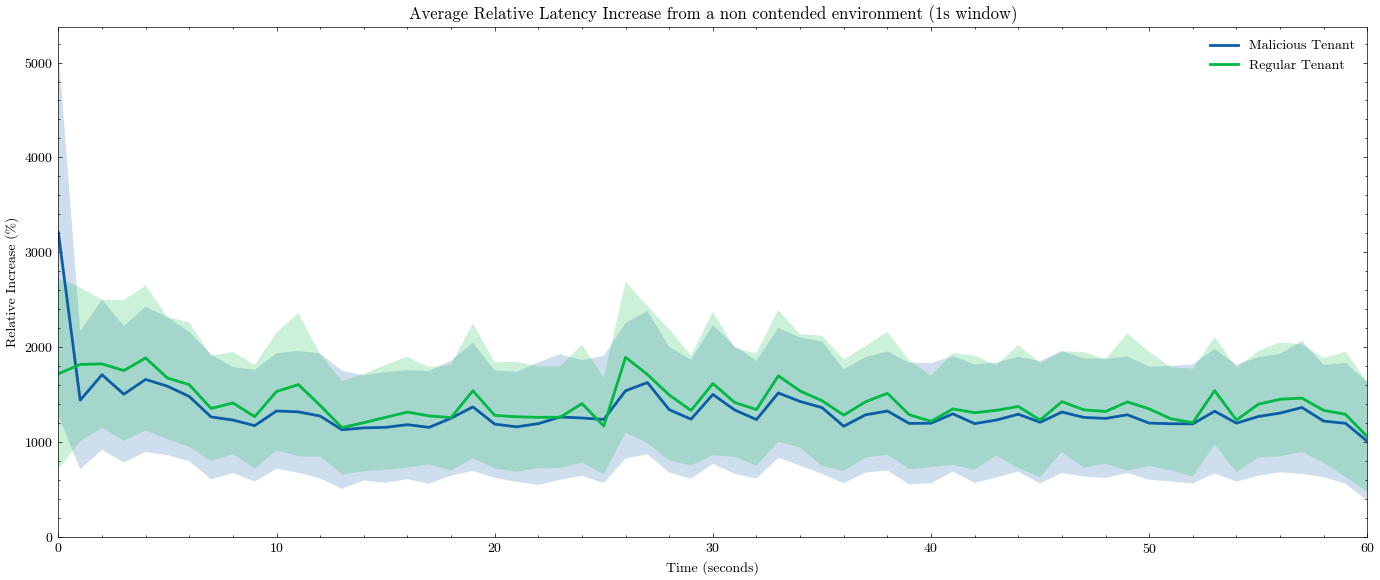

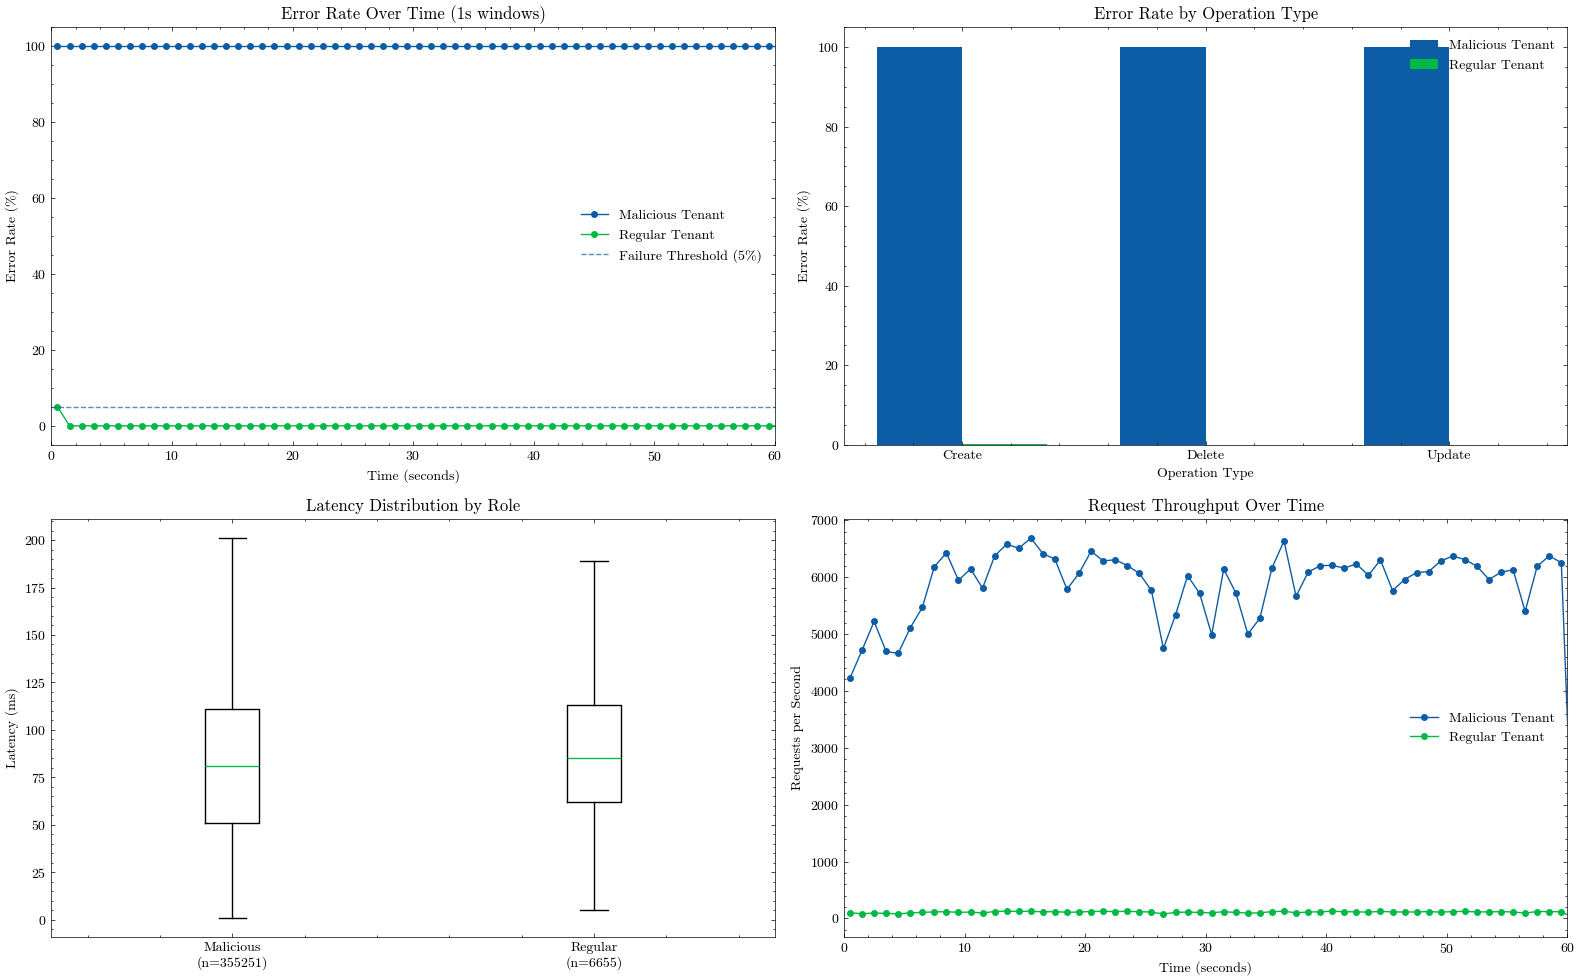

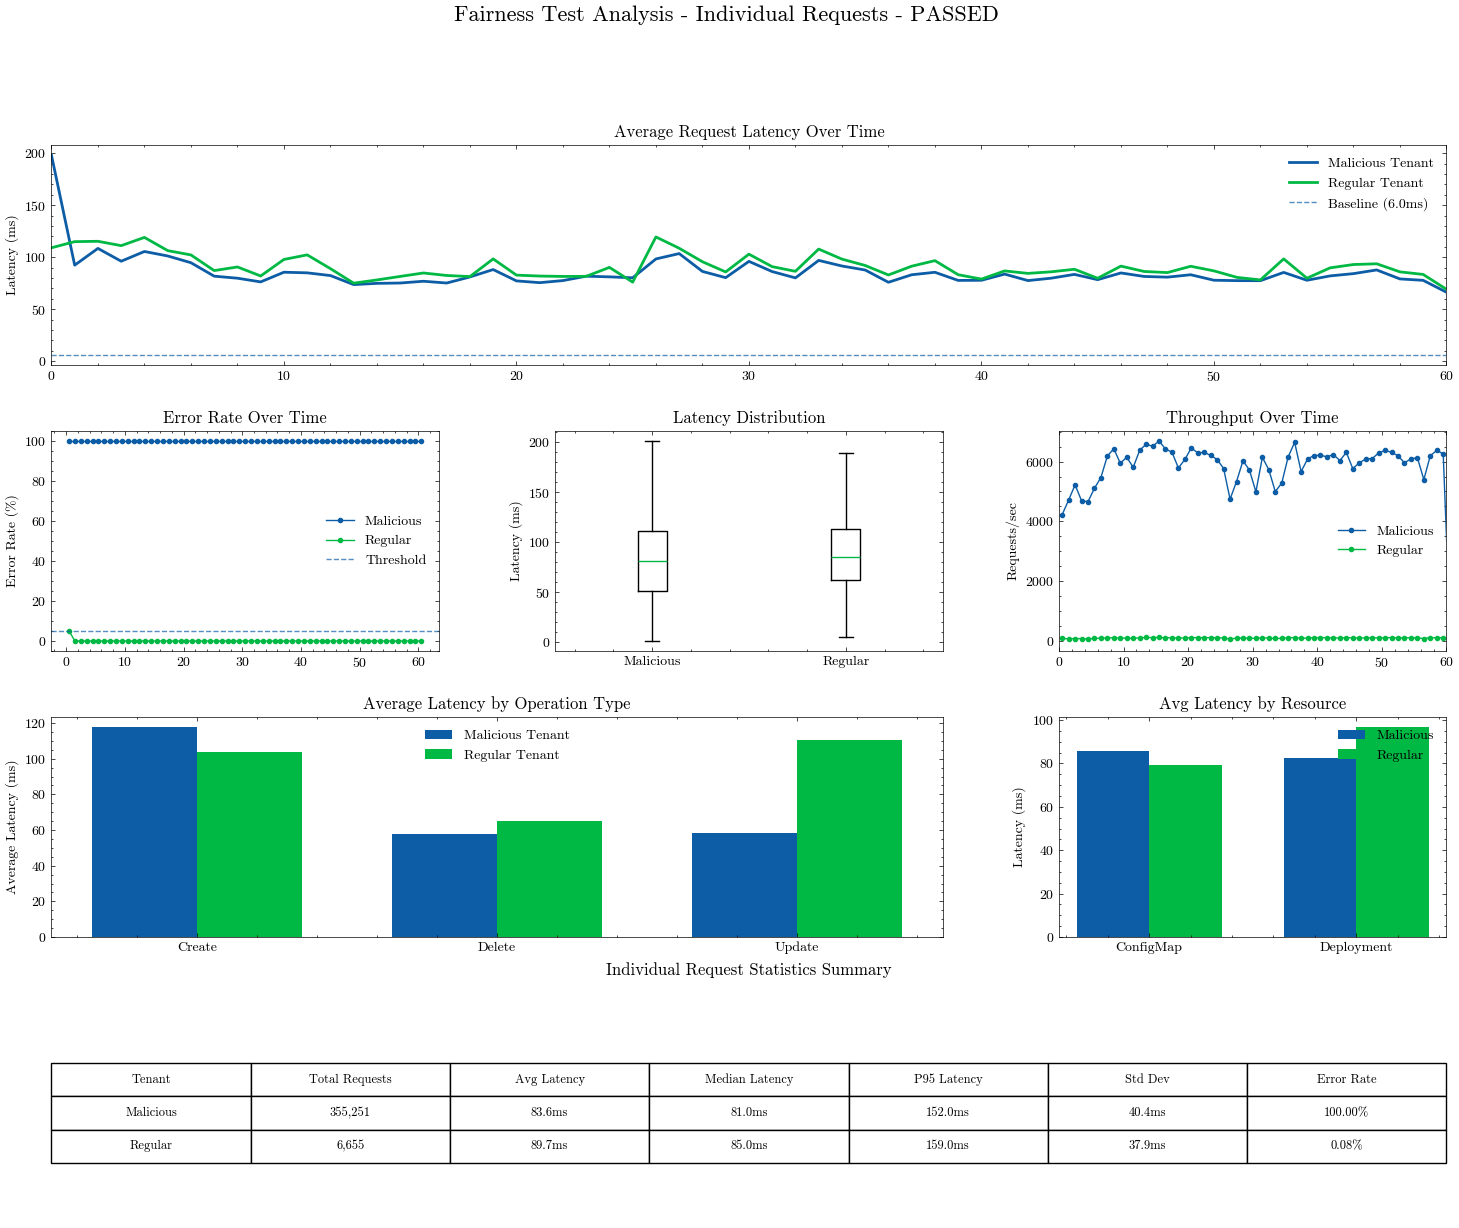


Analysis complete! Plots saved with timestamp: 1749511652
Total individual requests analyzed: 361,906


In [6]:
# Run the analysis
df, metadata = analyze_fairness_test("./60_sec/vcluster/data", "./60_sec/vcluster/results")

## Plot the data using KubeZoo

Loaded 35745 individual request records
Data columns: ['start_time', 'role', 'duration_ms', 'operation', 'resource', 'is_error']
Time range: 10.1 - 71.7
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 35,072
    Average Latency: 866.0ms
    Median Latency: 1018.0ms
    95th Percentile: 1531.0ms
    Standard Deviation: 364.2ms
    Error Rate: 0.00%
    Successful Requests: 35,072
    Failed Requests: 0

  Regular Tenant:
    Total Requests: 673
    Average Latency: 906.3ms
    Median Latency: 1018.0ms
    95th Percentile: 1531.0ms
    Standard Deviation: 480.0ms
    Error Rate: 2.08%
    Successful Requests: 659
    Failed Requests: 14

Baseline Comparison:
  Baseline Latency: 26.0ms
  Current Avg Latency: 906.3ms
  Relative Increa

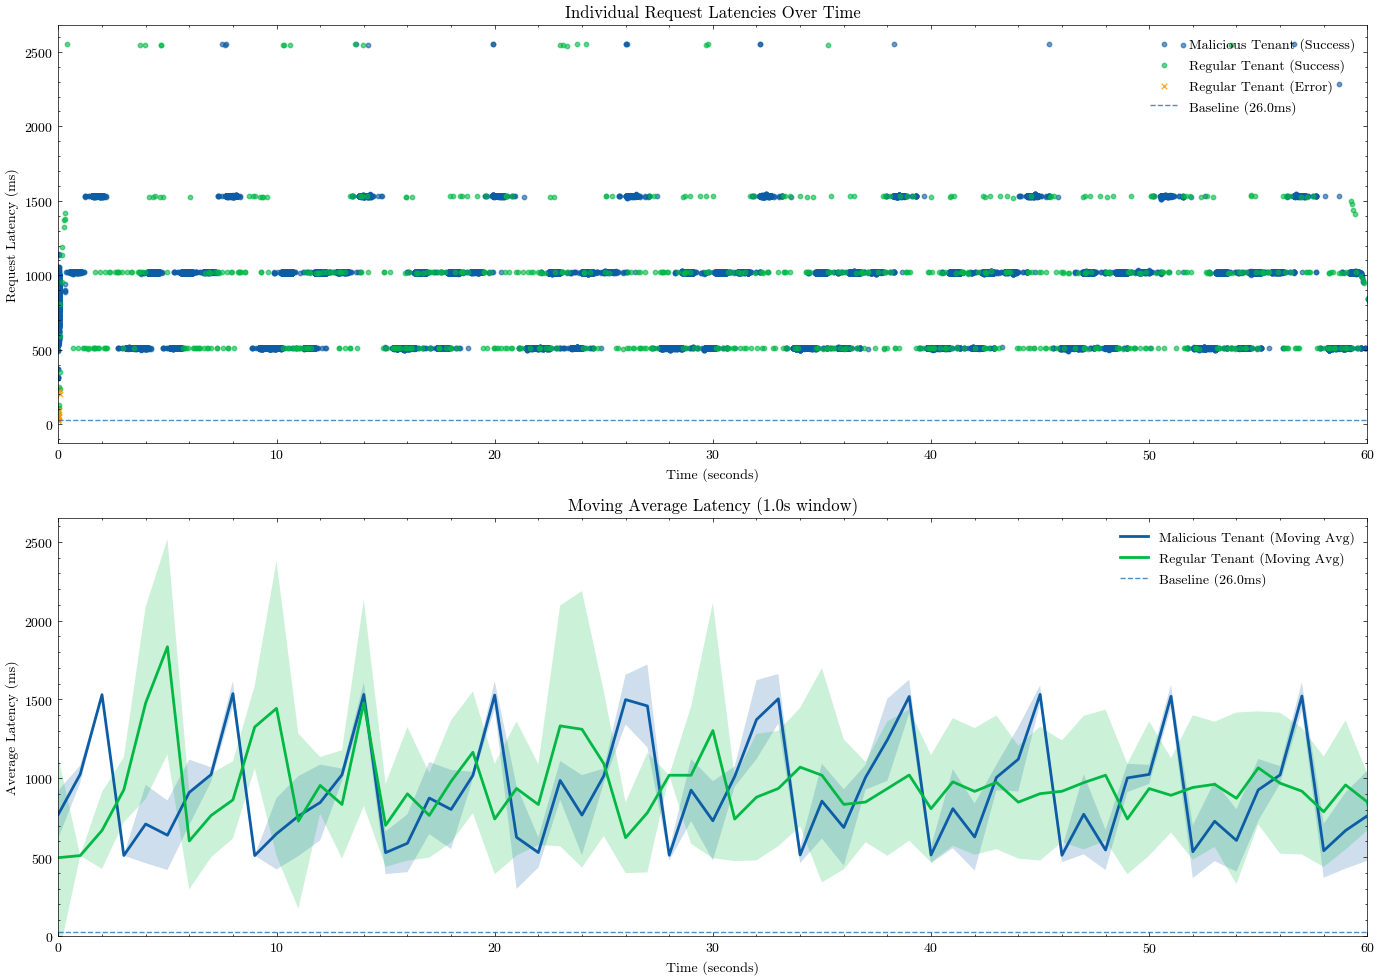

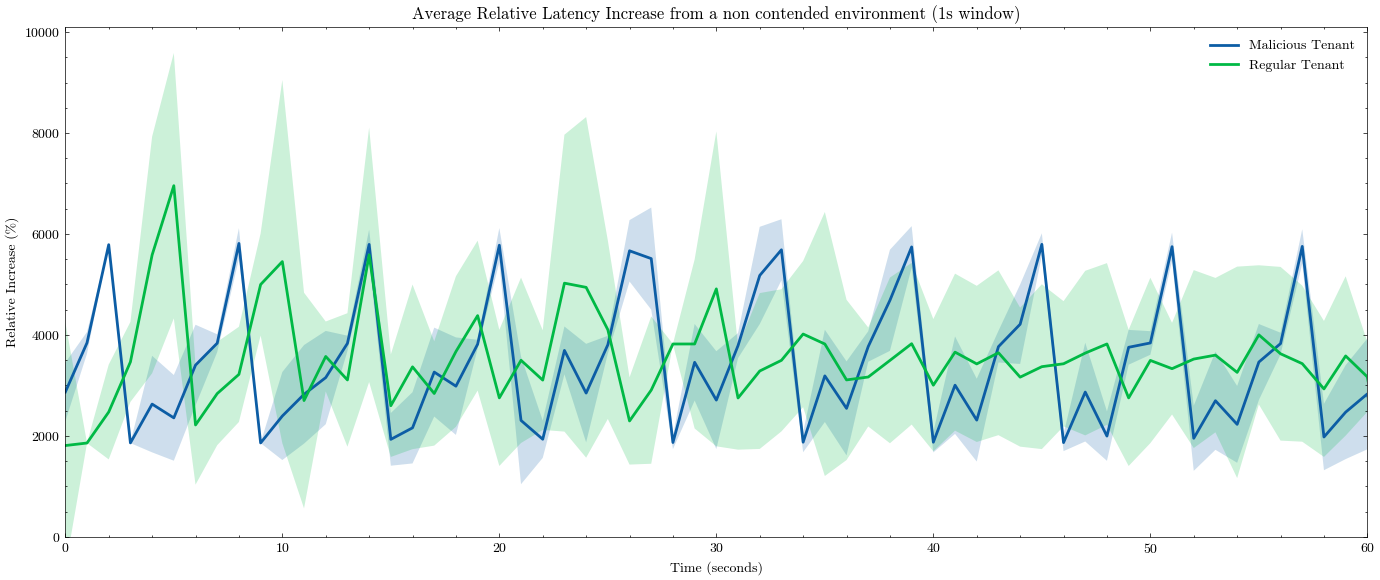

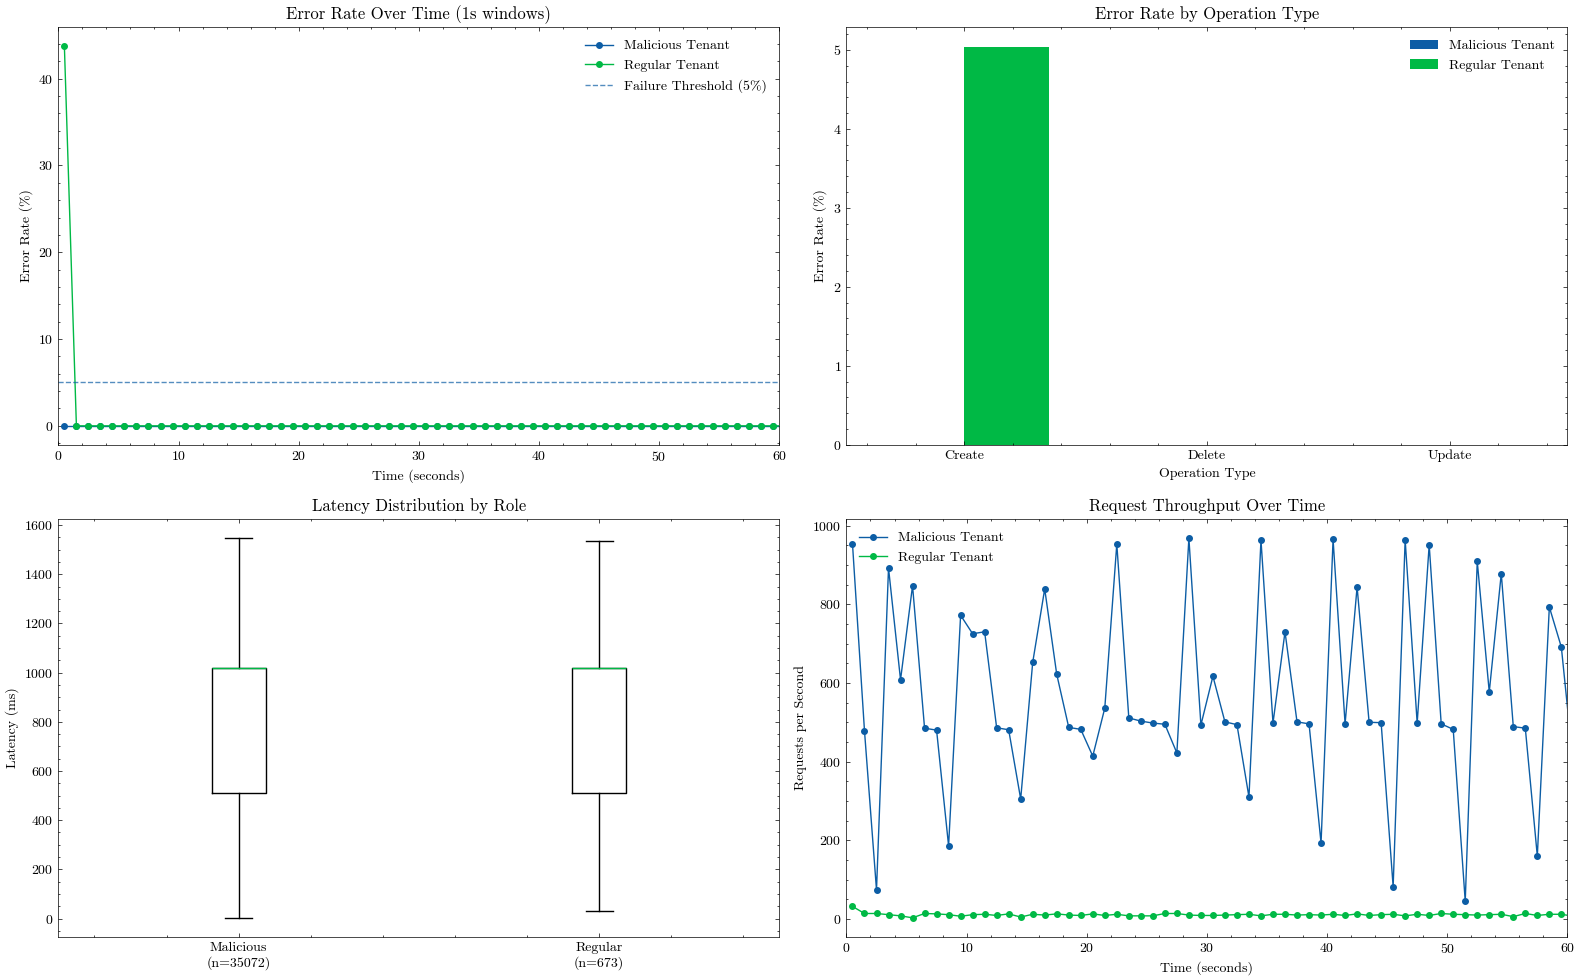

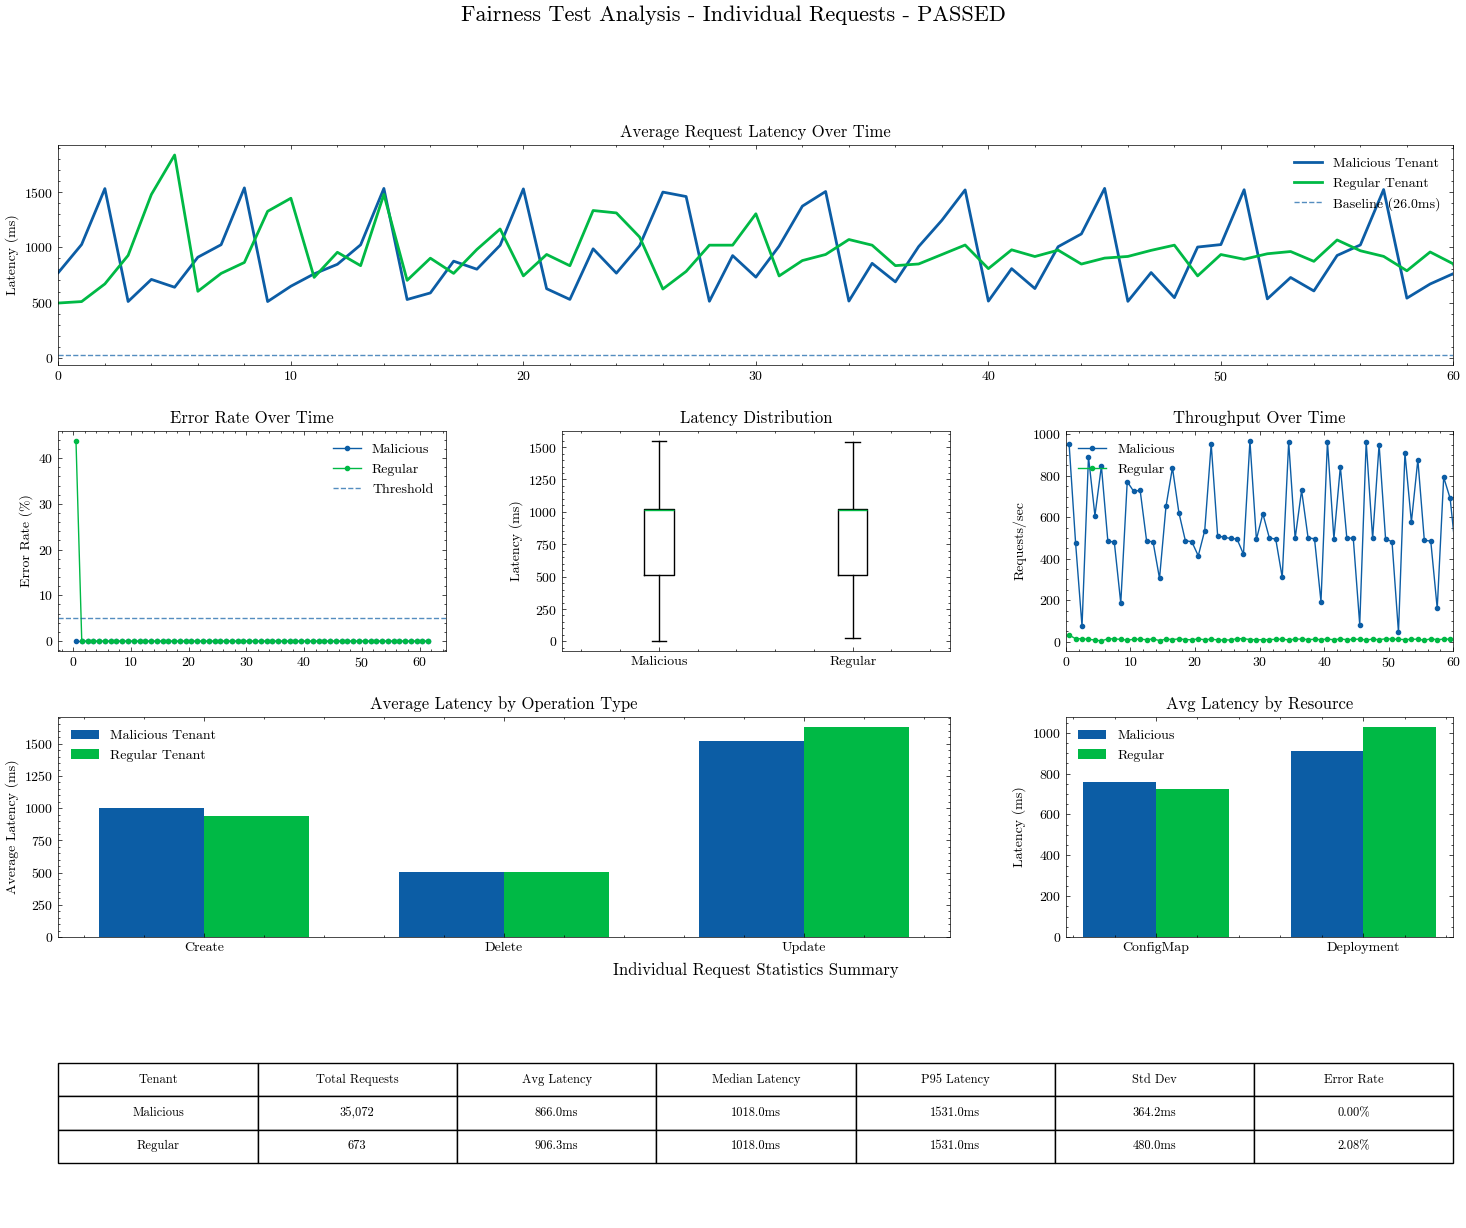


Analysis complete! Plots saved with timestamp: 1749514297
Total individual requests analyzed: 35,745


In [7]:
# Run the analysis
df, metadata = analyze_fairness_test("./60_sec/kubezoo/data", "./60_sec/kubezoo/results")

Loaded 112940 individual request records
Data columns: ['start_time', 'role', 'duration_ms', 'operation', 'resource', 'is_error']
Time range: 10.0 - 70.9
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 82,928
    Average Latency: 363.4ms
    Median Latency: 349.0ms
    95th Percentile: 572.0ms
    Standard Deviation: 122.7ms
    Error Rate: 0.00%
    Successful Requests: 82,928
    Failed Requests: 0

  Regular Tenant:
    Total Requests: 30,012
    Average Latency: 16.3ms
    Median Latency: 15.0ms
    95th Percentile: 30.0ms
    Standard Deviation: 7.5ms
    Error Rate: 0.02%
    Successful Requests: 30,005
    Failed Requests: 7

Baseline Comparison:
  Baseline Latency: 16.0ms
  Current Avg Latency: 16.3ms
  Relative Increase: 

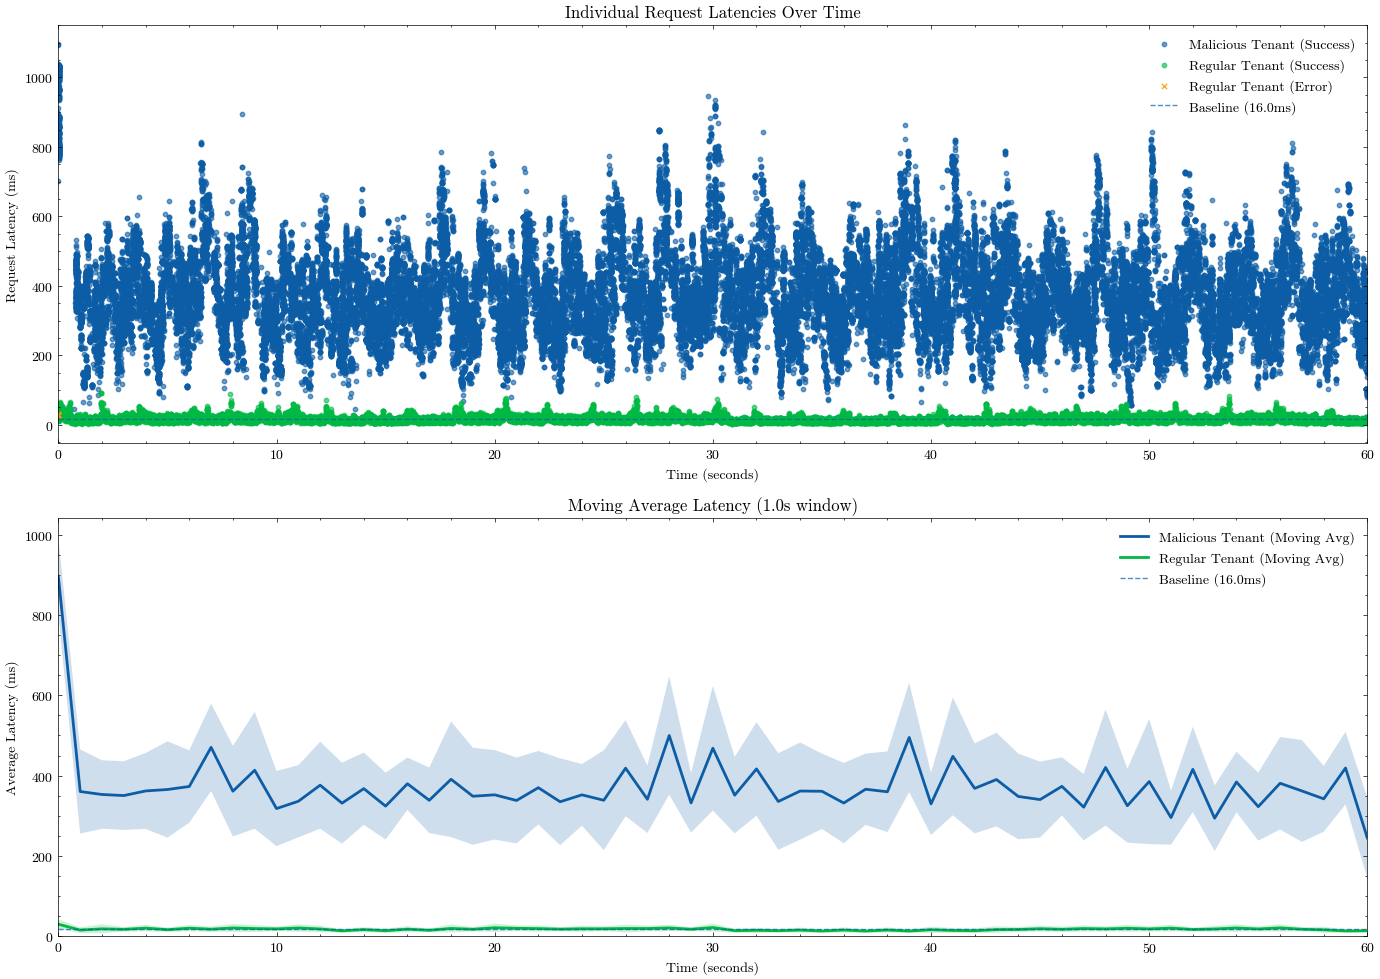

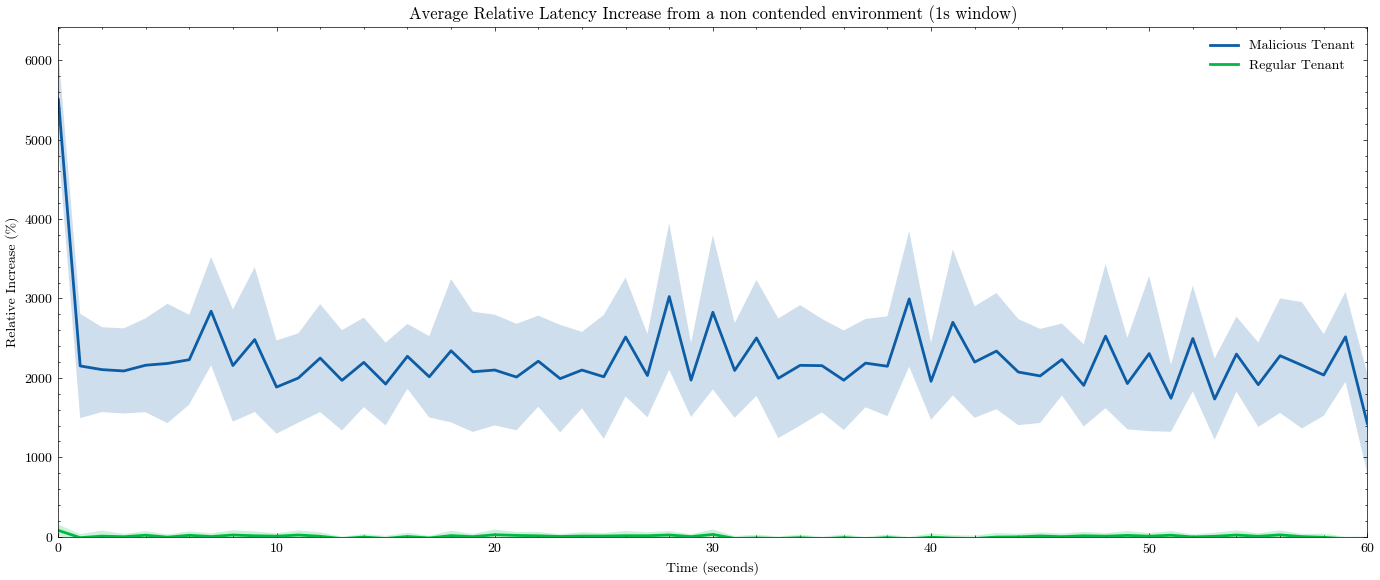

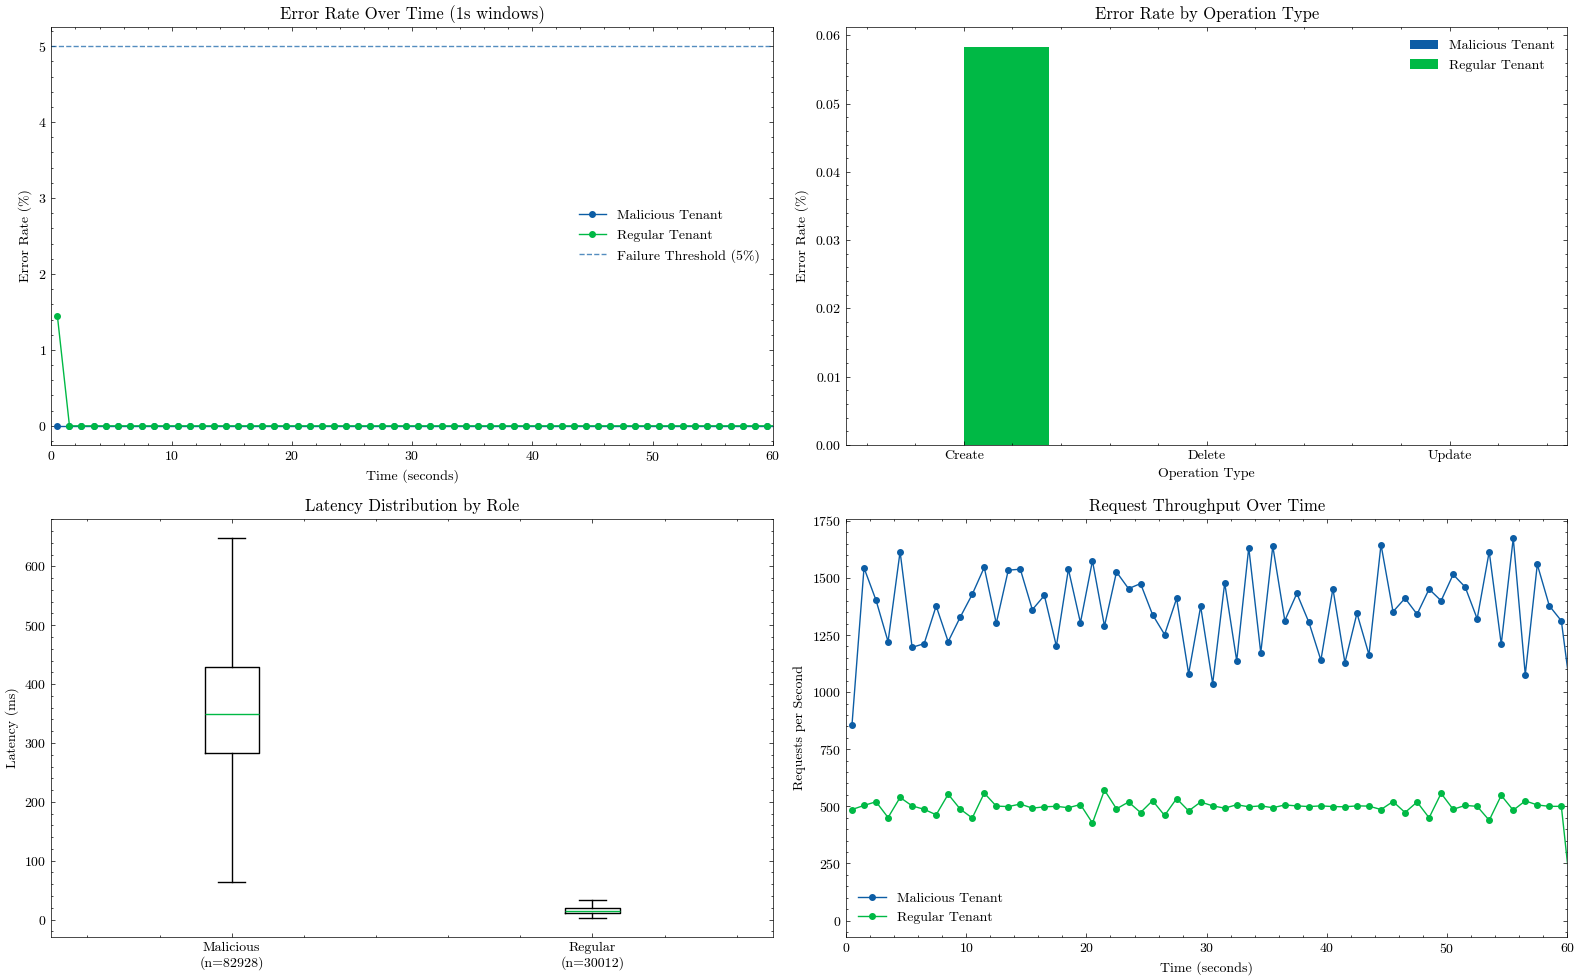

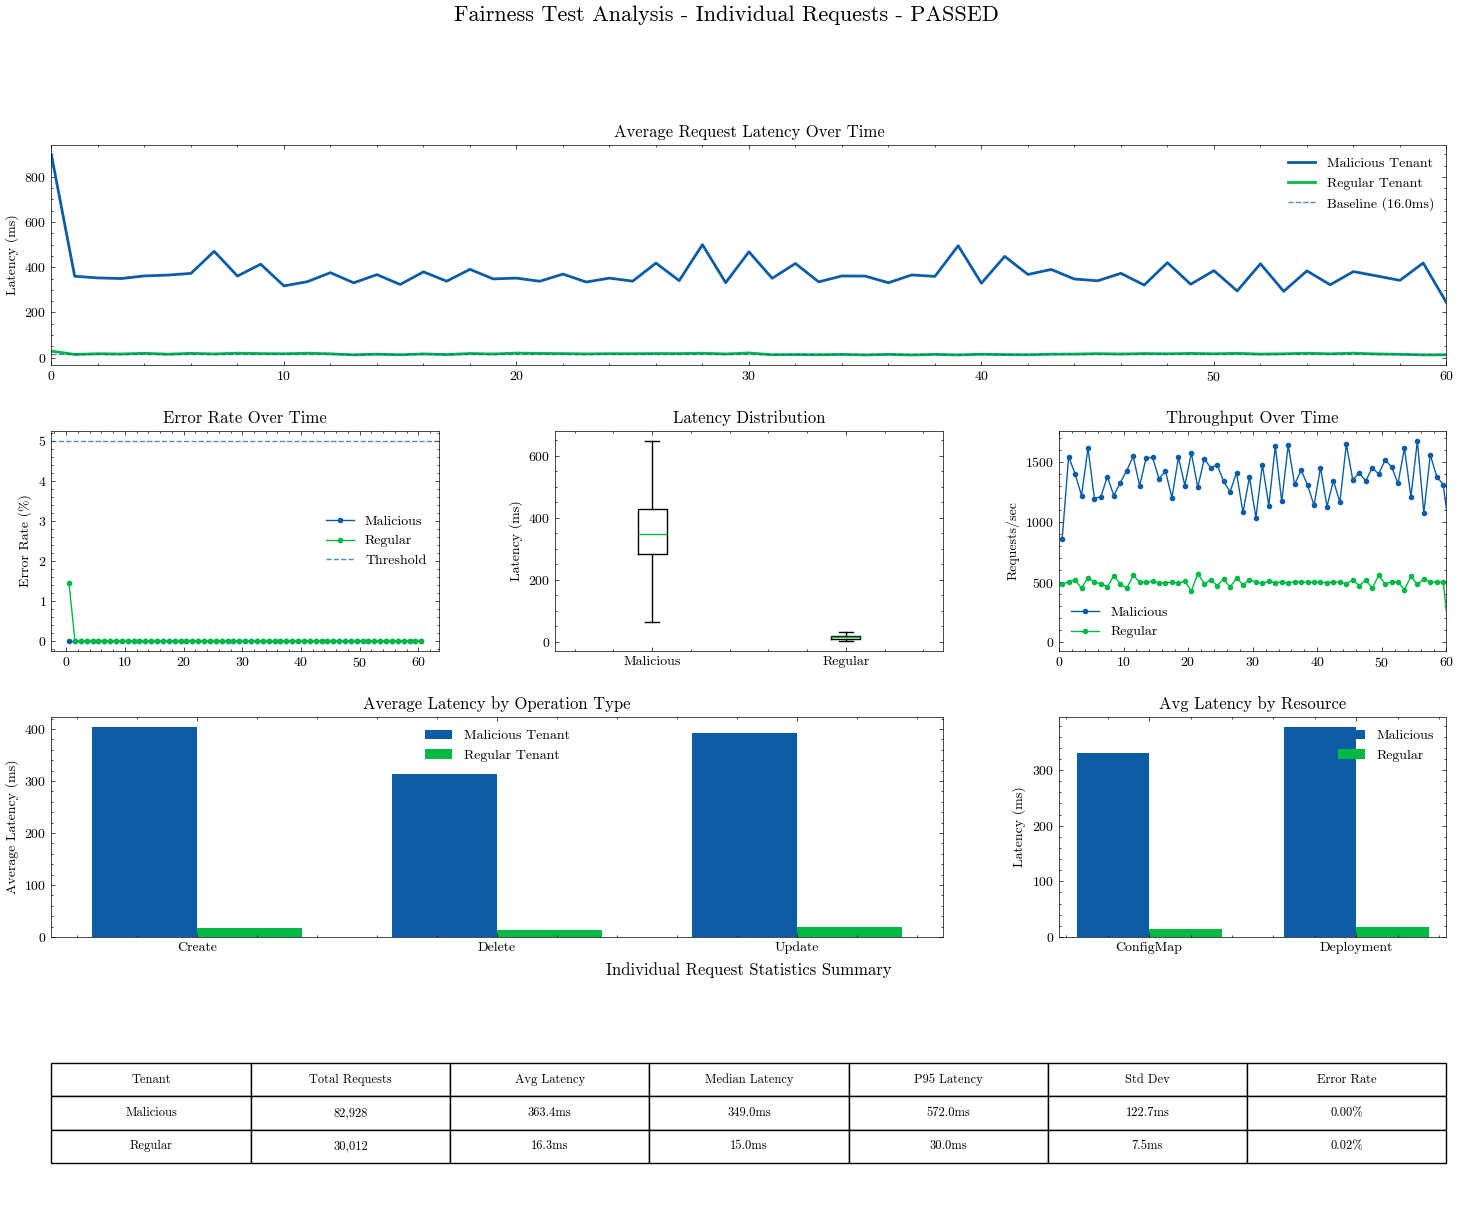


Analysis complete! Plots saved with timestamp: 1749508696
Total individual requests analyzed: 112,940


In [11]:
# Run the analysis
df, metadata = analyze_fairness_test("./60_sec/kubevirt/data", "./60_sec/kubevirt/results")